In [45]:
!pip install transformers datasets torchaudio librosa sentence-transformers -q
!pip install scikit-learn matplotlib seaborn -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import ClapModel, ClapProcessor, BertModel, BertTokenizer
from sentence_transformers import SentenceTransformer
import librosa
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings("ignore")

In [46]:
def load_cmu_book_summaries():
    try:
        import os
        if os.path.exists('/kaggle/input/datasets/ymaricar/cmu-book-summary-dataset/booksummaries.txt'):
            book_summaries = pd.read_csv('/kaggle/input/datasets/ymaricar/cmu-book-summary-dataset/booksummaries.txt', 
                                         sep='\t', header=None, 
                                         names=['Wikipedia ID', 'Freebase ID', 'Book Title', 
                                                'Book Author', 'Publication Date', 'Book Genre',
                                                'Summary'])
            
            return book_summaries
        else:
            return create_synthetic_book_summaries()
            
    except Exception as e:
        return create_synthetic_book_summaries()

books_df = load_cmu_book_summaries()
print(f"\nПример описания сюжета:")
print(books_df['Summary'].iloc[0][:200] + "...")


Пример описания сюжета:
 Old Major, the old boar on the Manor Farm, calls the animals on the farm for a meeting, where he compares the humans to parasites and teaches the animals a revolutionary song, 'Beasts of England'. Wh...


In [47]:
def load_yambda_50m_kaggle(
    data_dir: str = "/kaggle/input/datasets/ploshkin/yambda",
    sample_fraction: float = 0.1,
    n_emb_components: int = 64,
    cache: bool = True,
    random_state: int = 42
):
    import polars as pl
    import numpy as np
    from pathlib import Path
    from sklearn.decomposition import PCA
    import gc
    import warnings
    warnings.filterwarnings("ignore")
    
    data_path = Path(data_dir)
    cache_dir = Path("/kaggle/working/yambda_cache")
    
    if cache:
        cache_dir.mkdir(exist_ok=True)
        cache_pos = cache_dir / f"pos_{int(sample_fraction*100)}pct.parquet"
        cache_emb = cache_dir / f"emb_{n_emb_components}d.parquet"
        
        if cache_pos.exists() and cache_emb.exists():
            df_pos = pl.read_parquet(cache_pos)
            df_emb = pl.read_parquet(cache_emb)
            return df_pos, df_emb
    
        
    df_raw = pl.read_parquet("/kaggle/input/datasets/ploshkin/yambda/flat/50m/multi_event.parquet")
    
    df_yambda_pos = df_raw.filter(
        (pl.col("event_type") == "like") | 
        ((pl.col("event_type") == "listen") & (pl.col("played_ratio_pct") >= 70))
    ).select(["uid", "item_id", "timestamp"]).unique()
    
    if sample_fraction < 1.0:
        n_samples = int(len(df_yambda_pos) * sample_fraction)
        df_yambda_pos = df_yambda_pos.sample(n=n_samples, seed=random_state)
    
    df_yambda_pos = df_yambda_pos.sort("timestamp")
    
    del df_raw
    gc.collect()
        
    df_emb_raw = pl.read_parquet(
        "/kaggle/input/datasets/ploshkin/yambda/embeddings.parquet",
        columns=["item_id", "embed"]
    )
    
    target_items = set(df_yambda_pos["item_id"].to_list())
    
    df_emb_filtered = df_emb_raw.filter(pl.col("item_id").is_in(target_items))
    
    embed_list = df_emb_filtered["embed"].to_list()
    embed_matrix = np.vstack(embed_list).astype(np.float32)
    item_ids = df_emb_filtered["item_id"].to_list()
    
    pca = PCA(n_components=n_emb_components, random_state=random_state)
    embed_reduced = pca.fit_transform(embed_matrix).astype(np.float32)
    
    del embed_matrix, embed_list, df_emb_raw, df_emb_filtered
    gc.collect()
    
    df_yambda_emb = pl.DataFrame(
        embed_reduced,
        schema=[f"emb_{i}" for i in range(n_emb_components)],
        schema_overrides={f"emb_{i}": pl.Float32 for i in range(n_emb_components)}
    ).with_columns(pl.Series("item_id", item_ids))
    
    del embed_reduced, item_ids
    gc.collect()
        
    if cache:
        df_yambda_pos.write_parquet(cache_pos, compression="zstd")
        df_yambda_emb.write_parquet(cache_emb, compression="zstd")
    
    print(f"   Взаимодействия: {len(df_yambda_pos):,}")
    print(f"   Пользователей: {df_yambda_pos['uid'].n_unique():,}")
    print(f"   Треков: {df_yambda_pos['item_id'].n_unique():,}")
    print(f"   Эмбеддингов: {len(df_yambda_emb):,} × {n_emb_components}D")
    print(f"   RAM использовано: ~2-4 ГБ")
    
    return df_yambda_pos, df_yambda_emb

df_yambda, music_df = load_yambda_50m_kaggle(
    data_dir="/kaggle/input/ploshkin-yambda",
    sample_fraction=0.1,
    n_emb_components=64,
    cache=True
)

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")
model = ClapModel.from_pretrained("laion/clap-htsat-unfused")
model = model.to(device)
model.eval()

def get_audio_embedding_clap(audio_path=None, audio_array=None, sr=48000):
    if audio_array is None and audio_path is None:
        raise ValueError("Нужно указать audio_path или audio_array")
    
    if audio_path:
        audio, sr = librosa.load(audio_path, sr=sr, duration=30)
    else:
        audio = audio_array
    
    if np.max(np.abs(audio)) > 1:
        audio = audio / np.max(np.abs(audio))
    
    inputs = processor(audio=audio, return_tensors="pt", sampling_rate=sr)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        audio_features = model.get_audio_features(**inputs)
        
        if hasattr(audio_features, 'last_hidden_state'):
            embed = audio_features.last_hidden_state.mean(dim=1)
        elif hasattr(audio_features, 'pooler_output'):
            embed = audio_features.pooler_output
        else:
            embed = audio_features
    
    return embed.cpu()

def get_text_embedding_clap(text, max_length=512):
    if isinstance(text, str):
        text = [text]
        
    inputs = processor(
        text=text, 
        return_tensors="pt", 
        padding=True, 
        truncation=True, 
        max_length=max_length
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        text_features = model.get_text_features(**inputs)
        
        if hasattr(text_features, 'pooler_output') and text_features.pooler_output is not None:
            embed = text_features.pooler_output
        elif hasattr(text_features, 'last_hidden_state'):
            embed = text_features.last_hidden_state.mean(dim=1)
        else:
            embed = text_features
            
    return embed.cpu()


def get_text_embedding_clap_long(text, max_length=512, chunk_size=400):
    if isinstance(text, list):
        return torch.vstack([get_text_embedding_clap_long(t, max_length, chunk_size) for t in text])
    
    tokens = processor.tokenizer(text, return_tensors="pt", truncation=False)
    token_count = tokens["input_ids"].shape[1]
    
    if token_count <= max_length:
        return get_text_embedding_clap(text, max_length)
        
    
    import re
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    
    chunks, current_chunk, current_length = [], [], 0
    for sentence in sentences:
        s_tokens = len(processor.tokenizer(sentence)["input_ids"])
        if current_length + s_tokens > chunk_size and current_chunk:
            chunks.append(" ".join(current_chunk))
            overlap = current_chunk[-2:] if len(current_chunk) >= 2 else current_chunk[-1:]
            current_chunk = overlap + [sentence]
            current_length = sum(len(processor.tokenizer(s)["input_ids"]) for s in current_chunk)
        else:
            current_chunk.append(sentence)
            current_length += s_tokens
            
    if current_chunk:
        chunks.append(" ".join(current_chunk))
        
    chunk_embeddings = []
    for chunk in chunks:
        embed = get_text_embedding_clap(chunk, max_length)
        if embed.dim() == 3: embed = embed.squeeze(0)
        elif embed.dim() == 1: embed = embed.unsqueeze(0)
        chunk_embeddings.append(embed)
        
    final_embed = torch.mean(torch.stack(chunk_embeddings), dim=0, keepdim=False)
    if final_embed.dim() == 1:
        final_embed = final_embed.unsqueeze(0)
        
    return final_embed.cpu()

Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

In [49]:
def build_similarity_matrix(track_embeddings: np.ndarray, 
                           sentence_embeddings: np.ndarray) -> np.ndarray:
    similarity_matrix = cosine_similarity(track_embeddings, sentence_embeddings)
    return similarity_matrix

def optimal_segmentation_dp(similarity_matrix: np.ndarray, 
                           min_sentences_per_track: int = 1) -> List[Tuple[int, int]]:

    n_tracks, m_sentences = similarity_matrix.shape
    
    if m_sentences < n_tracks * min_sentences_per_track:
        raise ValueError(f"Недостаточно предложений: {m_sentences} < {n_tracks * min_sentences_per_track}")
    
    dp = np.full((n_tracks + 1, m_sentences + 1), -np.inf)
    dp[0][0] = 0
    
    parent = np.zeros((n_tracks + 1, m_sentences + 1), dtype=int)
    
    cumsum = np.zeros((n_tracks, m_sentences + 1))
    for i in range(n_tracks):
        for j in range(1, m_sentences + 1):
            cumsum[i, j] = cumsum[i, j-1] + similarity_matrix[i, j-1]
    
    for i in range(1, n_tracks + 1):
        for j in range(i * min_sentences_per_track, m_sentences + 1):
            for k in range((i-1) * min_sentences_per_track, j - min_sentences_per_track + 1):
                segment_similarity = cumsum[i-1, j] - cumsum[i-1, k]
                
                if dp[i-1][k] + segment_similarity > dp[i][j]:
                    dp[i][j] = dp[i-1][k] + segment_similarity
                    parent[i][j] = k
    
    segmentation = []
    j = m_sentences
    for i in range(n_tracks, 0, -1):
        k = parent[i][j]
        segmentation.append((k, j))
        j = k
    
    segmentation.reverse()
    return segmentation

def playlist_book_alignment_dp(playlist_embeddings: np.ndarray,
                               book_sentences_embeddings: np.ndarray,
                               book_title: str) -> Dict:
    similarity_matrix = build_similarity_matrix(playlist_embeddings, book_sentences_embeddings)
    
    segmentation = optimal_segmentation_dp(similarity_matrix)
    
    total_similarity = 0
    for i, (start, end) in enumerate(segmentation):
        segment_sim = similarity_matrix[i, start:end].mean()
        total_similarity += segment_sim
    
    avg_similarity = total_similarity / len(playlist_embeddings)
    
    return {
        'book_title': book_title,
        'similarity': avg_similarity,
        'segmentation': segmentation,
        'similarity_matrix': similarity_matrix
    }


In [50]:
class PlaylistBookDataset(Dataset):
    
    def __init__(self, playlist_embeddings, book_embeddings, strategy='in_batch'):
        self.playlist_embeddings = playlist_embeddings
        self.book_embeddings = book_embeddings
        self.strategy = strategy
        
    def __len__(self):
        return len(self.playlist_embeddings)
    
    def __getitem__(self, idx):
        playlist_emb = self.playlist_embeddings[idx]
        book_emb = self.book_embeddings[idx]
        
        return {
            'playlist': torch.FloatTensor(playlist_emb),
            'book': torch.FloatTensor(book_emb)
        }

class ContrastiveAligner(nn.Module):
    
    def __init__(self, embedding_dim=512, projection_dim=128):
        super().__init__()
        
        self.playlist_encoder = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.ReLU(),
            nn.Linear(256, projection_dim),
            nn.LayerNorm(projection_dim)
        )
        
        self.book_encoder = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.ReLU(),
            nn.Linear(256, projection_dim),
            nn.LayerNorm(projection_dim)
        )
    
    def forward(self, playlist_emb, book_emb):
        playlist_proj = self.playlist_encoder(playlist_emb)
        book_proj = self.book_encoder(book_emb)
        
        # Normalize для косинусной схожести
        playlist_proj = F.normalize(playlist_proj, p=2, dim=-1)
        book_proj = F.normalize(book_proj, p=2, dim=-1)
        
        return playlist_proj, book_proj

class InfoNCELoss(nn.Module):
    
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature
    
    def forward(self, playlist_proj, book_proj):
        batch_size = playlist_proj.shape[0]
        
        sim_matrix = torch.matmul(playlist_proj, book_proj.T) / self.temperature
        
        labels = torch.arange(batch_size).to(playlist_proj.device)
        
        loss = nn.CrossEntropyLoss()(sim_matrix, labels)
        
        return loss

def train_contrastive_model(music_df, books_df, epochs=30, batch_size=16, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    emb_cols = [c for c in music_df.columns if c.startswith('emb_')]
    
    if emb_cols:
        playlist_embeddings = music_df[emb_cols].to_numpy().astype(np.float32)
    elif 'embed' in music_df.columns:
        playlist_embeddings = np.vstack(music_df['embed'].to_list()).astype(np.float32)
    else:
        raise ValueError("Не найдены колонки эмбеддингов (emb_* или embed) в music_df")


    text_col = 'Summary' if 'Summary' in books_df.columns else 'description'
    book_texts = books_df[text_col].tolist()[:len(playlist_embeddings)]  # Ограничиваем длину

    book_embeddings = []
    for i, text in enumerate(book_texts):
        try:
            embed = get_text_embedding_clap_long(str(text))
            arr = embed.numpy() if hasattr(embed, 'numpy') else embed
            
            if arr.ndim == 3: arr = arr.squeeze(0)
            elif arr.ndim == 1: arr = arr.reshape(1, -1)
            book_embeddings.append(arr)
            
        except Exception as e:
            book_embeddings.append(np.zeros((1, 512)))

    book_embeddings = np.vstack(book_embeddings)

    min_len = min(len(playlist_embeddings), len(book_embeddings))
    playlist_embeddings = playlist_embeddings[:min_len]
    book_embeddings = book_embeddings[:min_len]

    dataset = PlaylistBookDataset(playlist_embeddings, book_embeddings, strategy='in_batch')
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = ContrastiveAligner(embedding_dim=playlist_embeddings.shape[1]).to(device)
    criterion = InfoNCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'loss': []}
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for batch in dataloader:
            playlist_emb = batch['playlist'].to(device)
            book_emb = batch['book'].to(device)
            
            optimizer.zero_grad()
            playlist_proj, book_proj = model(playlist_emb, book_emb)
            loss = criterion(playlist_proj, book_proj)
            
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(dataloader)
        history['loss'].append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"   Epoch {epoch+1}/{epochs}: Loss = {avg_loss:.4f}")

    return model, history

In [51]:
def visualize_sequence_alignment(segmentation, similarity_matrix, 
                                track_names, book_sentences):
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # 1. Тепловая карта матрицы похожести
    ax1 = axes[0]
    sns.heatmap(similarity_matrix, ax=ax1, cmap='YlOrRd',
               xticklabels=range(len(book_sentences)),
               yticklabels=track_names,
               cbar_kws={'label': 'Cosine Similarity'})
    ax1.set_title('Матрица похожести: Треки × Предложения', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Предложения в сюжете книги')
    ax1.set_ylabel('Треки в плейлисте')
    
    for i, (start, end) in enumerate(segmentation):
        ax1.axvline(start, color='blue', linestyle='--', alpha=0.5)
    
    ax2 = axes[1]
    colors = plt.cm.viridis(np.linspace(0, 1, len(track_names)))
    
    for i, (start, end) in enumerate(segmentation):
        ax2.barh(i, end - start, left=start, color=colors[i],
                label=f'{track_names[i]}: {end-start} предл.')
    
    ax2.set_xlabel('Индекс предложения в книге')
    ax2.set_ylabel('Треки в плейлисте')
    ax2.set_title('Распределение предложений по трекам', fontsize=14, fontweight='bold')
    ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

def visualize_user_clustering(playlists_df, books_df):
        
    music_features = playlists_df[['energy', 'valence', 'tempo']].values if 'energy' in playlists_df.columns else np.random.randn(len(playlists_df), 3)
    
    kmeans_music = KMeans(n_clusters=5, random_state=42)
    playlists_df['cluster'] = kmeans_music.fit_predict(music_features)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    pca_music = PCA(n_components=2)
    music_pca = pca_music.fit_transform(music_features)
    
    axes[0, 0].scatter(music_pca[:, 0], music_pca[:, 1], 
                      c=playlists_df['cluster'], cmap='viridis', alpha=0.6)
    axes[0, 0].set_title('Music User Clusters (PCA)', fontweight='bold')
    
    axes[0, 1].bar(*np.unique(playlists_df['cluster'], return_counts=True))
    axes[0, 1].set_title('Music Cluster Distribution', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return playlists_df

Token indices sequence length is longer than the specified maximum sequence length for this model (1199 > 512). Running this sequence through the model will result in indexing errors


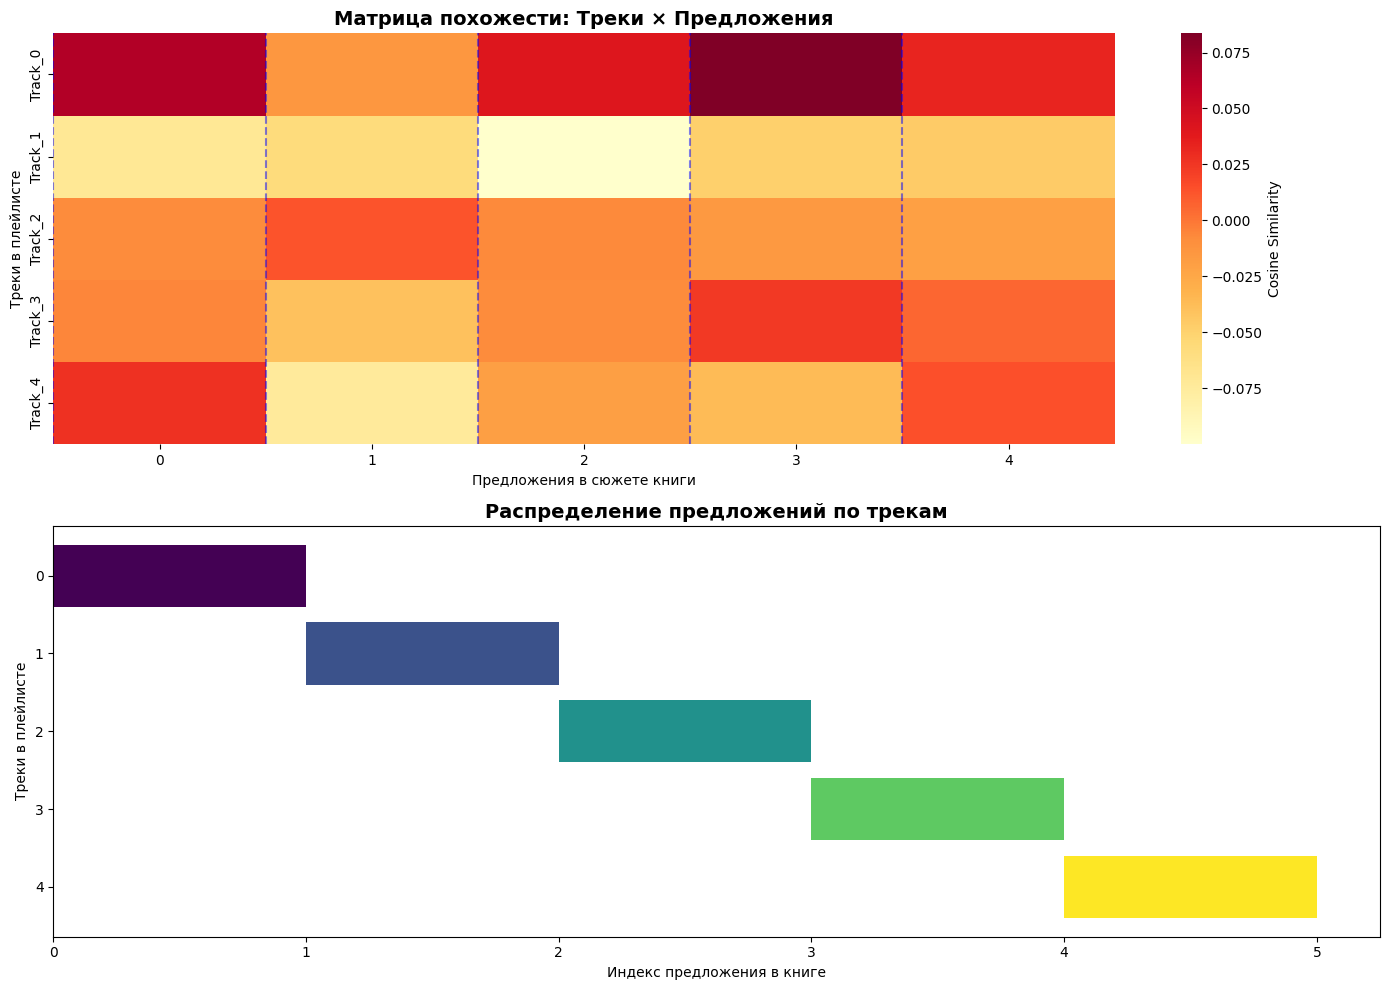

RuntimeError: mat1 and mat2 shapes cannot be multiplied (16x512 and 64x256)

In [52]:
def run_complete_pipeline():
    
    book_texts = books_df['Summary'].tolist()[:10]
    book_embeddings_raw = []
    
    for i, text in enumerate(book_texts):
        emb = get_text_embedding_clap_long(text)
        book_embeddings_raw.append(emb)
        # if (i + 1) % 5 == 0:
            # print(f"   Обработано {i+1} книг...")
    
    book_embeddings_list = []
    for emb in book_embeddings_raw:
        arr = emb.numpy() if hasattr(emb, 'numpy') else emb
        
        if arr.ndim == 3:
            arr = arr.squeeze(0)  # (1, 1, 512) -> (1, 512)
        elif arr.ndim == 1:
            arr = arr.reshape(1, -1) # (512,) -> (1, 512)
        
        book_embeddings_list.append(arr)
    
    book_embeddings = np.vstack(book_embeddings_list)
    
    n_tracks = 5
    playlist_embeddings = np.random.randn(n_tracks, 512).astype(np.float32)
    
    sample_book_idx = 0
    sample_sentences = book_texts[sample_book_idx].split('.')[:n_tracks]
    sample_sentences = [s.strip() for s in sample_sentences if s.strip()]
    
    sentence_embeddings_list = []
    for s in sample_sentences:
        emb = get_text_embedding_clap_long(s)
        arr = emb.numpy() if hasattr(emb, 'numpy') else emb
        if arr.ndim == 3: arr = arr.squeeze(0)
        elif arr.ndim == 1: arr = arr.reshape(1, -1)
        sentence_embeddings_list.append(arr)
    
    sentence_embeddings = np.vstack(sentence_embeddings_list)
    
    if len(sentence_embeddings) >= n_tracks:
        result = playlist_book_alignment_dp(
            playlist_embeddings,
            sentence_embeddings,
            books_df['Book Title'].iloc[sample_book_idx]
        )
        
        
        track_names = [f"Track_{i}" for i in range(len(result['segmentation']))]
        visualize_sequence_alignment(result['segmentation'], 
                                   result['similarity_matrix'],
                                   track_names, sample_sentences)

    model, history = train_contrastive_model(
        music_df, books_df,
        epochs=30, batch_size=16
    )
    
    music_clustered = visualize_user_clustering(music_df, books_df)
    
    return {
        'books': books_df,
        'music': music_df,
        'model': model,
        'history': history
    }

results = run_complete_pipeline()

In [ ]:
def save_results(results):
    if results is None:
        return
        
    try:
        if 'books' in results and results['books'] is not None:
            results['books'].to_csv('/content/books.csv', index=False)
            
        if 'music' in results and results['music'] is not None:
            results['music'].to_csv('/content/music.csv', index=False)
            
        if 'model' in results and results['model'] is not None:
            torch.save(results['model'].state_dict(), '/content/contrastive_model.pth')
            
        if 'history' in results and results['history']:
            import json
            with open('/content/training_history.json', 'w') as f:
                json.dump(results['history'], f)
            
        !zip -r /content/multimodal_recommendation_results.zip \
            /content/books.csv /content/music.csv /content/*.json 2>/dev/null
        
        
    except Exception as e:
        print(e)

save_results(results)